# 🧠🤖 Neurônio MCP 

Esta atividade tem como objetivo praticar a implementação do neurônio MCP usando numpy e seu uso em diferentes tarefas.

## Tarefa 1: Implementação com Numpy

A figura representa um neurônio de  McCulloch e Pitts (MCP). Crie uma classe para implementar este neurônio. Ela deve conter os seguintes métodos: 
- **construtor**: recebe um `numpy array` representando os pesos `w` e um número `b` representando o `bias`.
- **forward**: recebe um `numpy array` representando os valores que estão entrando no neurônio e gera como saída 1, se o neurônio se ativou, ou 0, caso contrário. O método deve realizar o produto interno entre entradas e pesos, somar o bias e aplicar a função de ativação.

🚨Na classe, o atributo que armazena os pesos deve necessariamente ser chamado de `w` e o bias deve ser `b`. 

![](assets/neuron.png)


In [1]:
import numpy as np

# resposta
class McpNeuron:
   def __init__(self, pesos: list[float], bias: float):
      self.w = pesos
      self.b = bias

   def forward(self, valores: list[float]): #multiplica cada valor pelo peso correspondente e verifica se fica maior que o bias
      total = valores @ self.w
      
      return int(total + self.b >= 0)


Abaixo são realizados alguns testes básicos para avaliar a implementação. Se tudo estiver certo, a palavra "ok" deve ser mostrada ao final.

In [2]:
w = np.array([1.2, 3.5])
b = -2
# Nome local: evita sobrescrever o `neuron` do classificador em dados.txt se esta célula for reexecutada.
neuron_verificacao = McpNeuron(w, b)

assert neuron_verificacao.forward(np.array([1, 0])) == 0, "resultado incorreto"
assert neuron_verificacao.forward(np.array([0, 1])) == 1, "resultado incorreto"
assert neuron_verificacao.forward(np.array([-1, 1])) == 1, "resultado incorreto"
assert neuron_verificacao.forward(np.array([1, -1])) == 0, "resultado incorreto"
assert neuron_verificacao.forward(np.array([-1, -1])) == 0, "resultado incorreto"
assert neuron_verificacao.forward(np.array([1, 1])) == 1, "resultado incorreto"
assert neuron_verificacao.forward(np.array([1, 2])) == 1, "resultado incorreto"
assert neuron_verificacao.forward(np.array([2, -3])) == 0, "resultado incorreto"

print("ok")

ok


## Tarefa 2: Classificador de Pontos

O arquivo  `dados.txt` contendo 3 números por linha. O primeiro número é a classe e o outros dois são as coordenadas do ponto. A sua tarefa é utilizar um neurônio MCP como classificador para separar os pontos de classes diferentes com a melhor performance possível considerando a base de dados (esperado acurácia superior a $90\%$). 

Implemente uma função que leia os dados do arquivo e armazene as coordenadas em um numpy array `X` e as classes em um numpy array `y`.

In [3]:
# resposta
def read_data(path):
    dados = np.loadtxt(path)
    ys = dados[:, 0].astype(int)
    xs = dados[:, 1:]

    return xs, ys

X, y = read_data("dados.txt")
print(X.shape, y.shape)

(220, 2) (220,)


A próxima célula contém funções para plotar os pontos como gráficos em 2D e em 3D.  Ela não precisa ser modificada.

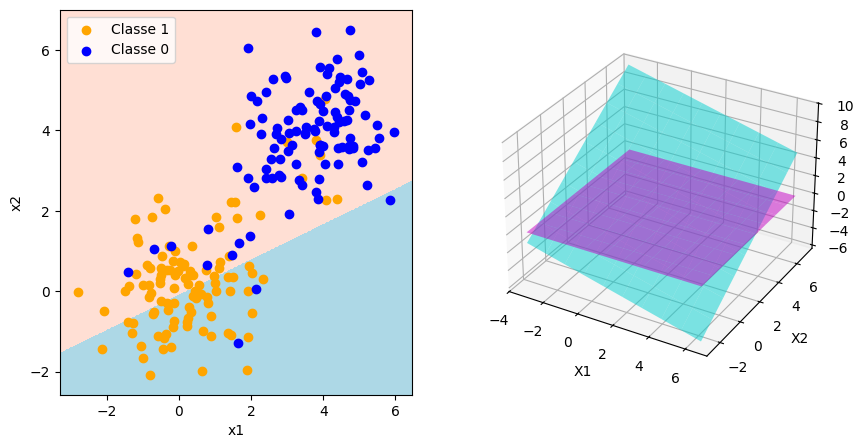

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def draw_classification_region(X, y, model=None):
    cmap_light = ListedColormap(['#ADD8E6', '#AAFFAA', '#ffdfd4'])

    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(121)

    h = .01
    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5
    y_min = X[:, 1].min() - 0.5
    y_max = X[:, 1].max() + 0.5

    if model:
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        Z = np.array([model.forward([x1, x2]) for x1, x2 in zip(xx.ravel(), yy.ravel())])
        Z = Z.reshape(xx.shape)
        ax.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

    ax.scatter(X[y == 1, 0], X[y == 1, 1], color='orange', label='Classe 1')
    ax.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', label='Classe 0')

    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

    ax.set_xlim((x_min, x_max))
    ax.set_ylim((y_min, y_max))
    ax.legend(loc='best')

    ax = fig.add_subplot(122, projection='3d')

    # Create grid
    x1 = np.linspace(*[x_min, x_max], 10)
    x2 = np.linspace(*[y_min, y_max], 10)
    X1, X2 = np.meshgrid(x1, x2)
    Z2 = 0 * X1 + 0 * X2 + 0

    ax.plot_surface(X1, X2, Z2, alpha=0.5, rstride=1,
                    cstride=1, color='magenta', edgecolor='none')

    if model:
        Z = model.w[0] * X1 + model.w[1] * X2 + model.b
        # Plot the surface
        ax.plot_surface(X1, X2, Z, alpha=0.5, rstride=1,
                        cstride=1, color='cyan', edgecolor='none')

    # Set labels
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('Z')


# Usa nome separado para não sobrescrever o `neuron` treinado nas células seguintes
# (nem ser sobrescrito ao reexecutar esta célula depois da solução).
demo_neuron = McpNeuron(np.array([-0.5, 1.14]), 0.1)
draw_classification_region(X, y, demo_neuron)

Na célula abaixo, ajuste os parâmetros do neurônio para maximizar a separação entre os pontos de classes diferentes.

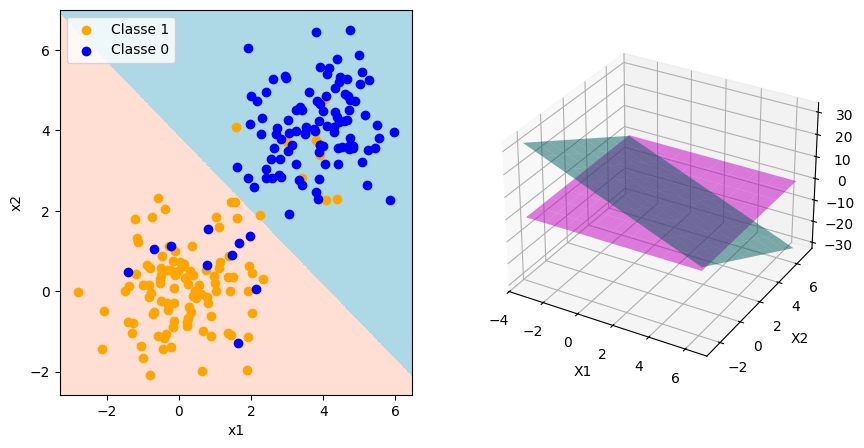

In [5]:
# resposta
mu0 = X[y == 0].mean(axis=0)
mu1 = X[y == 1].mean(axis=0)

w = mu1 - mu0
b = -0.5 * (mu1 + mu0) @ w

pred = (X @ w + b >= 0).astype(int)
if np.mean(pred == y) < 0.5:
    w = -w
    b = -b

neuron = McpNeuron(w, b)
draw_classification_region(X, y, neuron)

Para avaliar quantitativamente a qualidade da fronteira de decisão, implemente uma função para calcular a acurácia dados arrays do numpy representando as classes preditas e as classes esperadas.

In [6]:
# resposta
def accuracy(predictions, ground_truth):
    return np.mean(predictions == ground_truth)

prd = np.array([neuron.forward(x_i) for x_i in X])
acc = accuracy(prd, y)
acc


np.float64(0.9136363636363637)

## Tarefa 3: Classificador de Imagens

Nesta tarefa, vamos usar um neurônio MCP para implementar um classificador de imagens que separa digitos 0 de digitos 1. O treinamento do neurônio será feito por você! 

A célula abaixo importa as bibliotecas e faz o download e preparação da base de dados. Não é necessário modificá-la e ele pode demorar um pouco para terminar.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
mnist_X = mnist.data.astype('float32')
mnist_y = mnist.target.astype('int64')
mnist_X /= 255.0
mnist_X = (mnist_X * 2) - 1.0

ids = [idx for idx in range(len(mnist_y)) if mnist_y[idx] == 1 or mnist_y[idx] == 0]
mnist_X = mnist_X[ids]
mnist_y = mnist_y[ids]

print("x shape:", mnist_X.shape, "y shape:", mnist_y.shape)

x shape: (14780, 784) y shape: (14780,)


Vamos separar os dados em conjuntos independentes de treino ($80\%$) e teste ($20\%$), e visualizar algumas imagens.

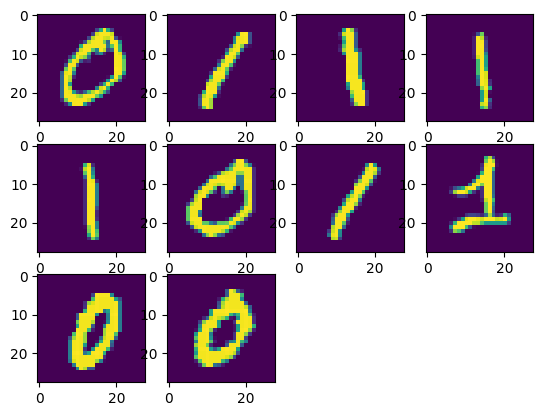

In [9]:
thresh = int(len(mnist_X) * 0.8)

train_x = mnist_X[:thresh]
train_y = mnist_y[:thresh]

test_x = mnist_X[thresh:]
test_y = mnist_y[thresh:]

for i in range(10):
    plt.subplot(3, 4, i+1)
    plt.imshow(train_x[i].reshape((28, 28)))


As próximas célular vão te guiar no processo de treinamento manual do neurônio MCP.

Calcule a média entre todas as imagens que são digitos 1 do conjunto de treino.

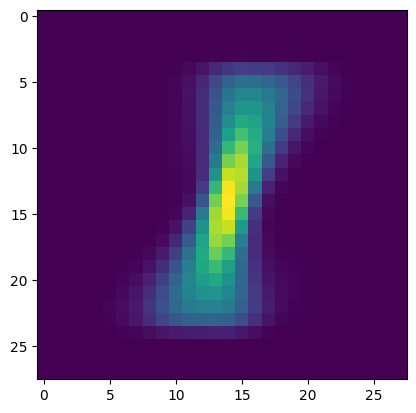

In [10]:
# resposta
imagem_media = np.mean(train_x[train_y == 1], axis=0)

plt.imshow(imagem_media.reshape((28, 28)))


Calcule o produto interno entre imagem média e todas as demais (de treino). Separe os valores para imagens que são 0 e imagens que são 1. Os valores devem ser armazenados em um numpy array. Tente realizar este cálculo usando operações matriciais.

In [11]:
# resposta
produtos_internos_1 = train_x[train_y == 1] @ imagem_media
produtos_internos_0 = train_x[train_y == 0] @ imagem_media

O próximo passo é um pouco sofisticado. Vamos tentar identificar um valor de corte para o produto interno de forma que: 
- o produto interno em relação a maioria das imagens 1 estejam acima deste limiar, 
- o produto interno em relação a maioria das imagens 0 estejam abaixo do limiar. 

Para isto, vamos plotar o histograma dos produtos internos. 

<Axes: xlabel='value', ylabel='Count'>

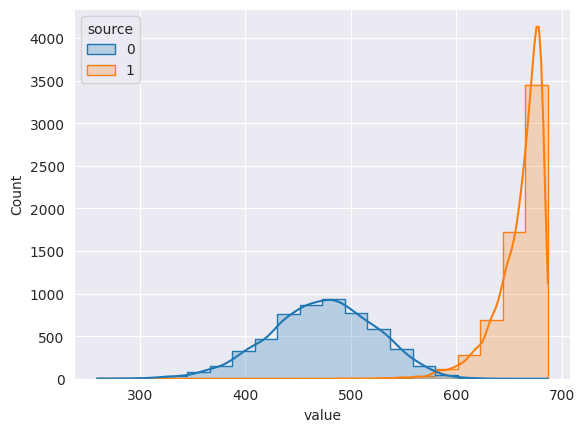

In [12]:
import pandas as pd
import seaborn as sns
sns.set_style("darkgrid")

# Create a DataFrame
df = pd.DataFrame({
    "value": np.concatenate([produtos_internos_0.squeeze(), produtos_internos_1.squeeze()]),
    "source": ["0"] * len(produtos_internos_0) + ["1"] * len(produtos_internos_1)
})

# Use 'hue' to automatically color and label different groups
plt.close('all')
sns.histplot(data=df, x="value", hue="source", element="step", bins=20, kde=True)

O histograma mostra os valores dos produtos internos no eixo X e a frequência com que eles aparecem no eixo y. Analisando o gráfico, identifique o valor de corte que serviria para fazer uma boa separação dos dados. 

Você lembra que o neurônio MCP retorna 1 quando $w \cdot x + b >= 0$  ou, equivalentemente, $w \cdot x >= b$  (ignorando o sinal de $b$) ? Se definirmos o vetor $w$ como sendo a imagem média dos 1s e $b$ como o valor de corte do produto interno, o neurônio vai responder classe 1 sempre que o produto interno for maior que o limite e 0 caso contrário. Como os produtos internos são bem diferentes para as duas classes, a performance do classificador será boa!


Crie um neurônio em que $w$ é a imagem média e $b$ é o negativo do limiar de forma que $w \cdot x + b$ seja maior que zero quando o produto interno for maior que o limiar.

In [13]:
# resposta
# Modelo MNIST em variável separada para manter `neuron` como o classificador 2D de dados.txt
# (validações automáticas costumam inspecionar `neuron` após executar o notebook inteiro).
neuron_mnist = McpNeuron(imagem_media, -(np.mean(produtos_internos_1) + np.mean(produtos_internos_0)) / 2)

Vamos calcular a acurácia deste neurônio para o conjunto de treino. Se tudo deu certo, é esperada uma performance acima $95\%$.

In [14]:
prd = np.array([neuron_mnist.forward(x) for x in train_x])
train_acc = accuracy(prd, train_y)
train_acc

np.float64(0.9869756427604871)

Vamos agora avaliar a performance no conjunto de teste. Aqui também é esperada uma performance acima de $95\%$. 

In [15]:
prd = np.array([neuron_mnist.forward(x) for x in test_x])
test_acc = accuracy(prd, test_y)
test_acc

# Restaurar `neuron` do classificador 2D em dados.txt (corretor / autojudge).
_mu0 = X[y == 0].mean(axis=0)
_mu1 = X[y == 1].mean(axis=0)
_w2 = _mu1 - _mu0
_b2 = -0.5 * (_mu1 + _mu0) @ _w2
_pred2 = (X @ _w2 + _b2 >= 0).astype(int)
if np.mean(_pred2 == y) < 0.5:
    _w2 = -_w2
    _b2 = -_b2
neuron = McpNeuron(_w2, _b2)


np.float64(0.9878213802435724)

🚨**Importante:** 🚨 Obviamente esta estratégia funcionou bem porque 1s e 0s são muito diferentes. Tente realizar o mesmo processo usando os digitos 3 e 8 e verifique que não existe um valor de corte que leve à uma performance tão alta.